In [1]:
import os
import sys
import importlib
import datetime
import requests
import getpass
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pandas.core.methods.describe import reorder_columns
from sympy.abc import alpha

from tqdm import tqdm
import pandas as pd
import numpy as np
from garth.exc import GarthException, GarthHTTPError
from garminconnect import (
    Garmin,
    GarminConnectAuthenticationError,
    GarminConnectConnectionError,
    GarminConnectTooManyRequestsError,
)

import lib

importlib.reload(lib)

project = lib.Project()
log = lib.getLogger(project.name)

DATE_FORMAT = '%Y-%m-%d'


# Garmin helper functions to interact with API
Taken from example file provided in documentation to ensure safe usage with API

In [2]:
def safe_api_call(api_method, *args, **kwargs):
    """
    Safe API call wrapper with comprehensive error handling.

    This demonstrates the error handling patterns used throughout the library.
    Returns (success: bool, result: Any, error_message: str)
    """
    try:
        result = api_method(*args, **kwargs)
        return True, result, None

    except GarthHTTPError as e:
        # Handle specific HTTP errors gracefully
        error_str = str(e)
        status_code = getattr(getattr(e, "response", None), "status_code", None)

        if status_code == 400 or "400" in error_str:
            return (
                False,
                None,
                "Endpoint not available (400 Bad Request) - Feature may not be enabled for your account",
            )
        elif status_code == 401 or "401" in error_str:
            return (
                False,
                None,
                "Authentication required (401 Unauthorized) - Please re-authenticate",
            )
        elif status_code == 403 or "403" in error_str:
            return (
                False,
                None,
                "Access denied (403 Forbidden) - Account may not have permission",
            )
        elif status_code == 404 or "404" in error_str:
            return (
                False,
                None,
                "Endpoint not found (404) - Feature may have been moved or removed",
            )
        elif status_code == 429 or "429" in error_str:
            return (
                False,
                None,
                "Rate limit exceeded (429) - Please wait before making more requests",
            )
        elif status_code == 500 or "500" in error_str:
            return (
                False,
                None,
                "Server error (500) - Garmin's servers are experiencing issues",
            )
        elif status_code == 503 or "503" in error_str:
            return (
                False,
                None,
                "Service unavailable (503) - Garmin's servers are temporarily unavailable",
            )
        else:
            return False, None, f"HTTP error: {e}"

    except FileNotFoundError:
        return (
            False,
            None,
            "No valid tokens found. Please login with your email/password to create new tokens.",
        )

    except GarminConnectAuthenticationError as e:
        return False, None, f"Authentication issue: {e}"

    except GarminConnectConnectionError as e:
        return False, None, f"Connection issue: {e}"

    except GarminConnectTooManyRequestsError as e:
        return False, None, f"Rate limit exceeded: {e}"

    except Exception as e:
        return False, None, f"Unexpected error: {e}"

def get_credentials():
    """Get email and password from environment or user input."""
    email = os.getenv("EMAIL")
    password = os.getenv("PASSWORD")

    if not email:
        email = input("Login email: ")
    if not password:
        password = getpass("Enter password: ")

    return email, password

def init_api() -> Garmin | None:
    """Initialize Garmin API with authentication and token management."""

    # Configure token storage
    tokenstore = os.getenv("GARMINTOKENS", "~/.garminconnect")
    tokenstore_path = Path(tokenstore).expanduser()

    print(f"🔐 Token storage: {tokenstore_path}")

    # Check if token files exist
    if tokenstore_path.exists():
        print("📄 Found existing token directory")
        token_files = list(tokenstore_path.glob("*.json"))
        if token_files:
            print(
                f"🔑 Found {len(token_files)} token file(s): {[f.name for f in token_files]}"
            )
        else:
            print("⚠️ Token directory exists but no token files found")
    else:
        print("📭 No existing token directory found")

    # First try to login with stored tokens
    try:
        print("🔄 Attempting to use saved authentication tokens...")
        garmin = Garmin()
        garmin.login(str(tokenstore_path))
        print("✅ Successfully logged in using saved tokens!")
        return garmin

    except (
        FileNotFoundError,
        GarthHTTPError,
        GarminConnectAuthenticationError,
        GarminConnectConnectionError,
    ):
        print("🔑 No valid tokens found. Requesting fresh login credentials.")

    # Loop for credential entry with retry on auth failure
    while True:
        try:
            # Get credentials
            email, password = get_credentials()

            print("� Logging in with credentials...")
            garmin = Garmin(
                email=email, password=password, is_cn=False, return_on_mfa=True
            )
            result1, result2 = garmin.login()

            if result1 == "needs_mfa":
                print("🔐 Multi-factor authentication required")

                mfa_code = input("Please enter your MFA code: ")
                print("🔄 Submitting MFA code...")

                try:
                    garmin.resume_login(result2, mfa_code)
                    print("✅ MFA authentication successful!")

                except GarthHTTPError as garth_error:
                    # Handle specific HTTP errors from MFA
                    error_str = str(garth_error)
                    if "429" in error_str and "Too Many Requests" in error_str:
                        print("❌ Too many MFA attempts")
                        print("💡 Please wait 30 minutes before trying again")
                        sys.exit(1)
                    elif "401" in error_str or "403" in error_str:
                        print("❌ Invalid MFA code")
                        print("💡 Please verify your MFA code and try again")
                        continue
                    else:
                        # Other HTTP errors - don't retry
                        print(f"❌ MFA authentication failed: {garth_error}")
                        sys.exit(1)

                except GarthException as garth_error:
                    print(f"❌ MFA authentication failed: {garth_error}")
                    print("💡 Please verify your MFA code and try again")
                    continue

            # Save tokens for future use
            garmin.garth.dump(str(tokenstore_path))
            print(f"💾 Authentication tokens saved to: {tokenstore_path}")
            print("✅ Login successful!")
            return garmin

        except GarminConnectAuthenticationError:
            print("❌ Authentication failed:")
            print("💡 Please check your username and password and try again")
            # Continue the loop to retry
            continue

        except (
            FileNotFoundError,
            GarthHTTPError,
            GarminConnectConnectionError,
            requests.exceptions.HTTPError,
        ) as err:
            print(f"❌ Connection error: {err}")
            print("💡 Please check your internet connection and try again")
            return None

        except KeyboardInterrupt:
            print("\n👋 Cancelled by user")
            return None


# Get Garmin client

In [3]:
api = init_api()

🔐 Token storage: /Users/christophermagno/.garminconnect
📄 Found existing token directory
🔑 Found 2 token file(s): ['oauth2_token.json', 'oauth1_token.json']
🔄 Attempting to use saved authentication tokens...
✅ Successfully logged in using saved tokens!


# Helper functions for datetime

In [4]:
def _get_date_string(date):
    return date.strftime(DATE_FORMAT)

def today():
    return datetime.date.today().strftime(DATE_FORMAT)


def get_date_range(start=None, rng=None):
    start = start or datetime.datetime.today()
    rng = rng or int(start.strftime('%j'))
    dates = reversed([start - datetime.timedelta(days=x) for x in range(rng)])
    return [x.strftime(DATE_FORMAT) for x in dates]


)# Helper functions to gather ando organize Garmin data

Some useful methods from the Garmin class to use
* get_stats - using
* get_steps_data
* get_daily_steps
* get_floors
* get_heart_rates - using
* get_sleep_data - using
* get_stress_data
* get_rhr_day
* get_hrv_data
* get_fitnessage_data - using

Others toook at
* get_activities
* get_activities_fordate
* get_earned_badges

In [5]:
def get_sleep_data(date):

    sleep_data = {}

    to_pop = [
        'id',
        'userProfilePK',
        'napTimeSeconds',
        'sleepWindowConfirmed',
        'sleepWindowConfirmationType',
        'autoSleepStartTimestampGMT',
        'autoSleepEndTimestampGMT',
        'sleepQualityTypePK',
        'sleepResultTypePK',
        'deviceRemCapable',
        'retro',
        'sleepFromDevice',
        'sleepScores',
        'sleepScoreInsight',
        'sleepScorePersonalizedInsight',
        'sleepVersion'
    ]

    data = safe_api_call(api.get_sleep_data, date)[1]

    sleep_data.update(data['dailySleepDTO'])
    if 'sleepScores' in sleep_data:
        sleep_data['sleepScore'] = sleep_data['sleepScores']['overall']['value']
        sleep_data['sleepScoreQuality'] = sleep_data['sleepScores']['overall']['qualifierKey']
        sleep_data['stressSleepQuality'] = sleep_data['sleepScores']['stress']['qualifierKey']
        sleep_data['awakeCountQuality'] = sleep_data['sleepScores']['awakeCount']['qualifierKey']
        sleep_data['remSleepQuality'] = sleep_data['sleepScores']['remPercentage']['qualifierKey']
        sleep_data['restlessnessSleepQuality'] = sleep_data['sleepScores']['restlessness']['qualifierKey']
        sleep_data['lightSleepQuality'] = sleep_data['sleepScores']['lightPercentage']['qualifierKey']
        sleep_data['deepSleepQuality'] = sleep_data['sleepScores']['deepPercentage']['qualifierKey']
    else:
        sleep_data['sleepScore'] = None
        sleep_data['sleepScoreQuality'] = None
        sleep_data['stressSleepQuality'] = None
        sleep_data['awakeCountQuality'] = None
        sleep_data['remSleepQuality'] = None
        sleep_data['restlessnessSleepQuality'] = None
        sleep_data['lightSleepQuality'] = None
        sleep_data['deepSleepQuality'] = None

    # result['sleepHeartRate'] = data['sleepHeartRate']
    sleep_data['avgOvernightHrv'] = data.get('avgOvernightHrv')
    sleep_data['hrvStatus'] = data.get('hrvStatus')
    sleep_data['restingHeartRate'] = data.get('restingHeartRate')

    for key in to_pop:
        try:
            sleep_data.pop(key)
        except KeyError as e:
            pass

    return sleep_data


In [6]:
def get_health_data(date):
    """
    """

    to_pop = [
        'userProfileId',
        'userDailySummaryId',
        'burnedKilocalories',
        'wellnessActiveKilocalories',
        'netRemainingKilocalories',
        'rule',
        'wellnessStartTimeGmt',
        'wellnessStartTimeLocal',
        'wellnessEndTimeGmt',
        'wellnessEndTimeLocal',
        'durationInMilliseconds',
        'wellnessDescription',
        'includesWellnessData',
        'includesActivityData',
        'includesCalorieConsumedData',
        'privacyProtected',
        'floorsAscended',
        'floorsDescended',
        'lastSevenDaysAvgRestingHeartRate',
        'source',
        'lastSyncTimestampGMT',
        'bodyBatteryMostRecentValue',
        'bodyBatteryVersion',
        'averageSpo2',
        'lowestSpo2',
        'latestSpo2',
        'latestSpo2ReadingTimeGmt',
        'latestSpo2ReadingTimeLocal',
        'latestSpo2ReadingTimeLocalaverageMonitoringEnvironmentAltitude',
        'restingCaloriesFromActivity',
        'latestRespirationValue',
        'latestRespirationTimeGMT',
        'respirationAlgorithmVersion',
        'ageGroup',
        'averageMonitoringEnvironmentAltitude',
        'bodyBatteryChargedValue',
        'bodyBatteryDrainedValue',
        'bodyBatteryHighestValue',
        'bodyBatteryLowestValue',
        'bodyBatteryDuringSleep',
        'wellnessKilocalories',
        'consumedKilocalories',
        'remainingKilocalories',
        'netCalorieGoal',
        'wellnessDistanceMeters',
        'userNote',
        'sleepingSeconds',
        'minAvgHeartRate',
        'maxAvgHeartRate',
        'abnormalHeartRateAlertsCount',
        'unmeasurableSleepSeconds',
        'measurableAsleepDuration',
        'measurableAwakeDuration',
        'stressPercentage',
        'restStressPercentage',
        'activityStressPercentage',
        'uncategorizedStressPercentage',
        'lowStressPercentage',
        'mediumStressPercentage',
        'highStressPercentage',
        'restStressDuration',
        'userFloorsAscendedGoal',
    ]

    health_data = safe_api_call(api.get_stats, date)[1]
    health_data['fitnessAge'] = int(safe_api_call(api.get_fitnessage_data, date)[1]['fitnessAge'])

    # Heart rate data
    hdata = safe_api_call(api.get_heart_rates, date)[1]['heartRateValues']
    if hdata:
        heart_rates = [v[1] for v in hdata if v[1] is not None]
        health_data['avgHeartRate'] = float(np.array(heart_rates).mean())

    health_data.update(get_sleep_data(date))

    for key in to_pop:
        try:
            health_data.pop(key)
        except KeyError as e:
            pass

    health_data_clean = {}
    for key, value in health_data.items():
        health_data_clean[lib.convert_camel_case(key).title()] = value

    return health_data_clean.pop('Uuid'), health_data_clean

# Get Health Data

In [7]:
dates = get_date_range()

In [8]:
overall_data = {}
for date in tqdm(dates):
    id, health_data = get_health_data(date)
    overall_data[id] = health_data


100%|██████████| 354/354 [02:36<00:00,  2.26it/s]


# Create the Health Dataframe

In [9]:
df = pd.DataFrame(overall_data).T.convert_dtypes()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354 entries, 8f2ddf09f3e04ac780a5470c4099a803 to c66a8141f18c4da98d70cb9e7c784fd8
Data columns (total 57 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Total Kilocalories             354 non-null    Int64  
 1   Active Kilocalories            354 non-null    Int64  
 2   Bmr Kilocalories               354 non-null    Int64  
 3   Total Steps                    353 non-null    Int64  
 4   Total Distance Meters          353 non-null    Int64  
 5   Calendar Date                  354 non-null    string 
 6   Daily Step Goal                354 non-null    Int64  
 7   Highly Active Seconds          354 non-null    Int64  
 8   Active Seconds                 354 non-null    Int64  
 9   Sedentary Seconds              354 non-null    Int64  
 10  Moderate Intensity Minutes     354 non-null    Int64  
 11  Vigorous Intensity Minutes     354 non-null    Int64  


In [11]:
df.columns.tolist()

['Total Kilocalories',
 'Active Kilocalories',
 'Bmr Kilocalories',
 'Total Steps',
 'Total Distance Meters',
 'Calendar Date',
 'Daily Step Goal',
 'Highly Active Seconds',
 'Active Seconds',
 'Sedentary Seconds',
 'Moderate Intensity Minutes',
 'Vigorous Intensity Minutes',
 'Floors Ascended In Meters',
 'Floors Descended In Meters',
 'Intensity Minutes Goal',
 'Min Heart Rate',
 'Max Heart Rate',
 'Resting Heart Rate',
 'Average Stress Level',
 'Max Stress Level',
 'Stress Duration',
 'Activity Stress Duration',
 'Uncategorized Stress Duration',
 'Total Stress Duration',
 'Low Stress Duration',
 'Medium Stress Duration',
 'High Stress Duration',
 'Stress Qualifier',
 'Body Battery At Wake Time',
 'Avg Waking Respiration Value',
 'Highest Respiration Value',
 'Lowest Respiration Value',
 'Fitness Age',
 'Sleep Time Seconds',
 'Sleep Start Timestamp G M T',
 'Sleep End Timestamp G M T',
 'Sleep Start Timestamp Local',
 'Sleep End Timestamp Local',
 'Deep Sleep Seconds',
 'Light Sleep 

In [12]:
remap_columns = {
    'Calendar Date': 'Date',

    'Fitness Age': 'Fitness Age',

    # Calories
    'Total Kilocalories': 'Calories',
    'Active Kilocalories': 'Active Calories',
    'Bmr Kilocalories': 'Resting Calories',

    # Heart Rate
    'Avg Heart Rate': 'Average Heart Rate',
    'Min Heart Rate': 'Min Heart Rate',
    'Max Heart Rate': 'Max Heart Rate',
    'Resting Heart Rate': 'Resting Heart Rate',
    'Hrv Status': 'Heart Rate Variability Qualifier',

    # Respiration
    'Avg Waking Respiration Value': 'Avg Waking Respiration Value',
    'Highest Respiration Value': 'Highest Respiration Value',
    'Lowest Respiration Value': 'Lowest Respiration Value',

    # Steps/Distance
    'Total Steps': 'Total Steps',
    'Total Distance Meters': 'Total Distance Meters',
    'Daily Step Goal': 'Daily Step Goal',

    # Floors
    'Floors Ascended In Meters': 'Floors Ascended In Meters',
    'Floors Descended In Meters': 'Floors Descended In Meters',

    # Activity
    'Active Seconds': 'Active Seconds',
    'Highly Active Seconds': 'Highly Active Seconds',
    'Sedentary Seconds': 'Sedentary Seconds',
    'Moderate Intensity Minutes': 'Moderate Intensity Minutes',
    'Vigorous Intensity Minutes': 'Vigorous Intensity Minutes',
    'Intensity Minutes Goal': 'Intensity Minutes Goal',

    # Stress
    'Average Stress Level': 'Average Stress Level',
    'Total Stress Duration': 'Total Stress Seconds',
    'Stress Duration': 'Stress Seconds',
    'Max Stress Level': 'Max Stress Level',
    'Uncategorized Stress Duration': 'Uncategorized Stress Seconds',
    'Low Stress Duration': 'Low Stress Seconds',
    'Medium Stress Duration': 'Medium Stress Seconds',
    'High Stress Duration': 'High Stress Seconds',
    'Activity Stress Duration': 'Activity Stress Seconds',
    'Stress Qualifier': 'Stress Qualifier',

    # Body battery
    'Body Battery At Wake Time': 'Body Battery',

    # Sleep data
    'Sleep Start Timestamp G M T': 'Sleep Start Timestamp GMT',
    'Sleep End Timestamp G M T': 'Sleep End Timestamp GMT',
    'Sleep Start Timestamp Local': 'Sleep Start Timestamp Local',
    'Sleep End Timestamp Local': 'Sleep End Timestamp Local',

    'Sleep Time Seconds': 'Sleep Time Seconds',
    'Sleep Score': 'Sleep Score',
    'Sleep Score Quality': 'Sleep Quality',
    'Sleep Score Feedback': 'Sleep Feedback',

    'Light Sleep Seconds': 'Light Sleep Seconds',
    'Deep Sleep Seconds': 'Deep Sleep Seconds',
    'Rem Sleep Seconds': 'Rem Sleep Seconds',
    'Awake Sleep Seconds': 'Awake Sleep Seconds',

    'Average Respiration Value': 'Average Respiration Value',
    'Awake Count': 'Awake Count',
    'Avg Sleep Stress': 'Avg Sleep Stress',

    'Stress Sleep Quality': 'Stress Sleep Quality',
    'Awake Count Quality': 'Awake Count Quality',
    'Rem Sleep Quality': 'Rem Sleep Quality',
    'Restlessness Sleep Quality': 'Restlessness Sleep Quality',
    'Light Sleep Quality': 'Light Sleep Quality',
    'Deep Sleep Quality': 'Deep Sleep Quality',

    'Avg Overnight Hrv': 'Average Overnight Hrv',
}

In [13]:
df = df[remap_columns.keys()]
df = df.rename(columns=remap_columns)
df

,Date,Fitness Age,Calories,Active Calories,Resting Calories,Average Heart Rate,Min Heart Rate,Max Heart Rate,Resting Heart Rate,Heart Rate Variability Qualifier,...,Average Respiration Value,Awake Count,Avg Sleep Stress,Stress Sleep Quality,Awake Count Quality,Rem Sleep Quality,Restlessness Sleep Quality,Light Sleep Quality,Deep Sleep Quality,Average Overnight Hrv
8f2ddf09f3e04ac780a5470c4099a803,2025-01-01,30,2322,833,1489,<NA>,48,139,50,<NA>,...,13,2,11,EXCELLENT,FAIR,EXCELLENT,FAIR,FAIR,FAIR,<NA>
4ab88cfdf283481fa593979341aa8332,2025-01-02,30,1960,471,1489,<NA>,53,131,55,<NA>,...,13,0,35,POOR,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,EXCELLENT,<NA>
a6433536e16a492e8a7655909869ea9c,2025-01-03,30,1878,389,1489,<NA>,49,130,52,<NA>,...,13,3,14,GOOD,FAIR,EXCELLENT,FAIR,GOOD,FAIR,<NA>
8709a878c8b8459f8769c1ff58d886d3,2025-01-04,30,2388,899,1489,<NA>,49,142,52,<NA>,...,13,2,17,FAIR,FAIR,FAIR,FAIR,FAIR,EXCELLENT,<NA>
e929e59be1114b58a17d010d389233ed,2025-01-05,30,2536,1047,1489,<NA>,59,142,57,<NA>,...,14,4,41,POOR,POOR,POOR,POOR,POOR,FAIR,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3c68feb2861848a6884e16690bed0fff,2025-12-16,31,1927,410,1517,72.175362,49,122,51,BALANCED,...,13,0,12,EXCELLENT,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,FAIR,64
b66ae2c8866943f09ee44c9c702e6464,2025-12-17,31,1791,274,1517,70.95,49,113,52,BALANCED,...,14,0,12,EXCELLENT,EXCELLENT,GOOD,EXCELLENT,GOOD,EXCELLENT,58
0249e5d497ac4ce18d6e9896606ee2fa,2025-12-18,30,3154,1637,1517,83.961111,51,147,54,BALANCED,...,15,1,17,FAIR,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,EXCELLENT,54
5f3d7033f28b4c96ad99f91a13cdde7e,2025-12-19,30,3092,1575,1517,83.591667,49,154,51,BALANCED,...,13,0,20,FAIR,EXCELLENT,GOOD,EXCELLENT,EXCELLENT,EXCELLENT,55


# Convert some types

In [14]:
for col in ['Sleep Start Timestamp GMT', 'Sleep End Timestamp GMT', 'Sleep Start Timestamp Local', 'Sleep End Timestamp Local']:
    df[col] = pd.to_datetime(df[col], unit='ms')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354 entries, 8f2ddf09f3e04ac780a5470c4099a803 to c66a8141f18c4da98d70cb9e7c784fd8
Data columns (total 57 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Date                              354 non-null    string        
 1   Fitness Age                       354 non-null    Int64         
 2   Calories                          354 non-null    Int64         
 3   Active Calories                   354 non-null    Int64         
 4   Resting Calories                  354 non-null    Int64         
 5   Average Heart Rate                142 non-null    Float64       
 6   Min Heart Rate                    354 non-null    Int64         
 7   Max Heart Rate                    354 non-null    Int64         
 8   Resting Heart Rate                345 non-null    Int64         
 9   Heart Rate Variability Qualifier  132 non-null    string        


# Export the data

In [16]:
df.to_csv(project.raw_file)

# Read the data to explore

In [17]:
df = lib.read_data(project.raw_file)

PortfolioLogger.lib.tools: INFO: Encoding: ascii
PortfolioLogger.lib.tools: INFO: Stripping whitespaces from raw_data.csv
PortfolioLogger.lib.performance: INFO: <function read_data at 0x1159cccc0> took 0.030 secs to complete.


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        354 non-null    object 
 1   Date                              354 non-null    object 
 2   Fitness Age                       354 non-null    int64  
 3   Calories                          354 non-null    int64  
 4   Active Calories                   354 non-null    int64  
 5   Resting Calories                  354 non-null    int64  
 6   Average Heart Rate                142 non-null    float64
 7   Min Heart Rate                    354 non-null    int64  
 8   Max Heart Rate                    354 non-null    int64  
 9   Resting Heart Rate                345 non-null    float64
 10  Heart Rate Variability Qualifier  132 non-null    object 
 11  Avg Waking Respiration Value      354 non-null    int64  
 12  Highest 

# Some Initial queries
Take out 'maxStressLevel'?

In [19]:
agg_columns = [
    'Calories',
    'Active Calories',
    'Total Steps',
    'Average Heart Rate',
    'Min Heart Rate',
    'Max Heart Rate',
    'Resting Heart Rate',
    'Average Stress Level',
    'Max Stress Level',
    'Sleep Score',
]

agg_distance = [
    'Total Distance Meters'
]


agg_seconds = [
    'Active Seconds',
    'Sedentary Seconds',
    'Sleep Time Seconds'
]

agg_minutes = [

    'Moderate Intensity Minutes',
    'Vigorous Intensity Minutes',
]

In [20]:
for item in agg_columns:
    log.info(
        f'{item}'
        f'\n\tMax {item}: {df[item].max():.2f} '
        f'\n\tMin {item}: {df[item].min():.2f} '
        f'\n\tMean {item}: {df[item].mean():.2f}'
    )

PortfolioLogger.Health Overview: INFO: Calories
	Max Calories: 4134.00 
	Min Calories: 506.00 
	Mean Calories: 2361.62
PortfolioLogger.Health Overview: INFO: Active Calories
	Max Active Calories: 2617.00 
	Min Active Calories: 0.00 
	Mean Active Calories: 857.67
PortfolioLogger.Health Overview: INFO: Total Steps
	Max Total Steps: 36384.00 
	Min Total Steps: 21.00 
	Mean Total Steps: 10759.33
PortfolioLogger.Health Overview: INFO: Average Heart Rate
	Max Average Heart Rate: 91.67 
	Min Average Heart Rate: 64.65 
	Mean Average Heart Rate: 75.52
PortfolioLogger.Health Overview: INFO: Min Heart Rate
	Max Min Heart Rate: 62.00 
	Min Min Heart Rate: 32.00 
	Mean Min Heart Rate: 50.45
PortfolioLogger.Health Overview: INFO: Max Heart Rate
	Max Max Heart Rate: 179.00 
	Min Max Heart Rate: 88.00 
	Mean Max Heart Rate: 131.78
PortfolioLogger.Health Overview: INFO: Resting Heart Rate
	Max Resting Heart Rate: 65.00 
	Min Resting Heart Rate: 39.00 
	Mean Resting Heart Rate: 53.95
PortfolioLogger.Hea

In [21]:
for item in agg_distance:
    log.info(
        f'{item}'
        f'\n\tMax {item}: {df[item].max():.2f} '
        f'\n\tMin {item}: {df[item].min():.2f} '
        f'\n\tMean {item}: {df[item].mean():.2f}'
    )

PortfolioLogger.Health Overview: INFO: Total Distance Meters
	Max Total Distance Meters: 26162.00 
	Min Total Distance Meters: 15.00 
	Mean Total Distance Meters: 7743.66


In [22]:
def seconds_to_hour(seconds):
    return seconds / 3600

def minutes_to_hour(minutes):
    return minutes / 60

In [23]:
for item in agg_seconds:
    max = seconds_to_hour(df[item].max())
    min = seconds_to_hour(df[item].min())
    mean = seconds_to_hour(df[item].mean())
    log.info(
        f'{item}'
        f'\n\tMax {item}: {max:.2f} '
        f'\n\tMin {item}: {min:.2f} '
        f'\n\tMean {item}: {mean:.2f}'
    )

PortfolioLogger.Health Overview: INFO: Active Seconds
	Max Active Seconds: 5.47 
	Min Active Seconds: 0.00 
	Mean Active Seconds: 2.28
PortfolioLogger.Health Overview: INFO: Sedentary Seconds
	Max Sedentary Seconds: 23.39 
	Min Sedentary Seconds: 4.39 
	Mean Sedentary Seconds: 12.23
PortfolioLogger.Health Overview: INFO: Sleep Time Seconds
	Max Sleep Time Seconds: 13.57 
	Min Sleep Time Seconds: 3.02 
	Mean Sleep Time Seconds: 7.39


In [24]:
max_cal_row = df[df['Calories'] == df['Calories'].max()]
min_cal_row = df[df['Calories'] == df['Calories'].min()]
mean_calories_burned = df['Calories'].mean()
total_days_overburn = len(df[df['Calories'] >= mean_calories_burned])
total_days_underburn = len(df[df['Calories'] <= df['Resting Calories'].mean() + 25])

log.info(f'Average Calories burned {mean_calories_burned:.2f} ')
log.info(f'Total days where I burned more than the mean: {total_days_overburn:.2f} ')
log.info(f'Total days where I burned less than than my metabolic rate: {total_days_underburn:.2f} ')
log.info(f'Max Calories burned: {max_cal_row.loc[max_cal_row.index[0], 'Calories']} on {max_cal_row.loc[max_cal_row.index[0], 'Date']} ')
log.info(f'Min Calories burned: {min_cal_row.loc[min_cal_row.index[0], 'Calories']} on {min_cal_row.loc[min_cal_row.index[0], 'Date']} ')

PortfolioLogger.Health Overview: INFO: Average Calories burned 2361.62 
PortfolioLogger.Health Overview: INFO: Total days where I burned more than the mean: 170.00 
PortfolioLogger.Health Overview: INFO: Total days where I burned less than than my metabolic rate: 8.00 
PortfolioLogger.Health Overview: INFO: Max Calories burned: 4134 on 2025-05-13 
PortfolioLogger.Health Overview: INFO: Min Calories burned: 506 on 2025-12-20 


# Visualizing the Data

In [455]:
MAIN_COLOR = 'coral'
REF_COLOR = 'gold'
POSITIVE_REF_COLOR = 'forestgreen'
NEGATIVE_REF_COLOR = 'crimson'
TIME_RANGE = int(187/2)
TIME_STEP = 5
df_viz = df.iloc[-TIME_RANGE:]
df_viz

,Unnamed: 0,Date,Fitness Age,Calories,Active Calories,Resting Calories,Average Heart Rate,Min Heart Rate,Max Heart Rate,Resting Heart Rate,...,Average Respiration Value,Awake Count,Avg Sleep Stress,Stress Sleep Quality,Awake Count Quality,Rem Sleep Quality,Restlessness Sleep Quality,Light Sleep Quality,Deep Sleep Quality,Average Overnight Hrv
261,0da8b76ddd554ba2898b4dd7ec2a301a,2025-09-19,32,3180,1663,1517,85.440278,47,144,53.0,...,14.0,1.0,24.0,FAIR,GOOD,EXCELLENT,EXCELLENT,EXCELLENT,EXCELLENT,52.0
262,48c74f1e8c3a442faff10a23760e25bc,2025-09-20,31,1941,424,1517,69.441667,46,125,47.0,...,14.0,0.0,13.0,EXCELLENT,EXCELLENT,EXCELLENT,EXCELLENT,EXCELLENT,EXCELLENT,63.0
263,20085aed19e54e03bbf4822671f04bfe,2025-09-21,32,2499,982,1517,76.125000,45,135,47.0,...,14.0,1.0,10.0,EXCELLENT,FAIR,EXCELLENT,FAIR,FAIR,FAIR,65.0
264,89e6b46006b14dbe84b5f778739eaeb4,2025-09-22,31,2689,1172,1517,78.887500,46,133,49.0,...,13.0,1.0,15.0,GOOD,GOOD,FAIR,GOOD,EXCELLENT,GOOD,55.0
265,918754a2a20444d2ad965bcf58ad2358,2025-09-23,31,1592,75,1517,75.098485,50,125,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,3c68feb2861848a6884e16690bed0fff,2025-12-16,31,1927,410,1517,72.175362,49,122,51.0,...,13.0,0.0,12.0,EXCELLENT,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,FAIR,64.0
350,b66ae2c8866943f09ee44c9c702e6464,2025-12-17,31,1791,274,1517,70.950000,49,113,52.0,...,14.0,0.0,12.0,EXCELLENT,EXCELLENT,GOOD,EXCELLENT,GOOD,EXCELLENT,58.0
351,0249e5d497ac4ce18d6e9896606ee2fa,2025-12-18,30,3154,1637,1517,83.961111,51,147,54.0,...,15.0,1.0,17.0,FAIR,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,EXCELLENT,54.0
352,5f3d7033f28b4c96ad99f91a13cdde7e,2025-12-19,30,3092,1575,1517,83.591667,49,154,51.0,...,13.0,0.0,20.0,FAIR,EXCELLENT,GOOD,EXCELLENT,EXCELLENT,EXCELLENT,55.0


## Total Calories Burned
Max is 3556 Calories burned

In [529]:
df_viz.loc[:, 'rolling avg'] = df_viz['Calories'].rolling(window=7).mean()

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


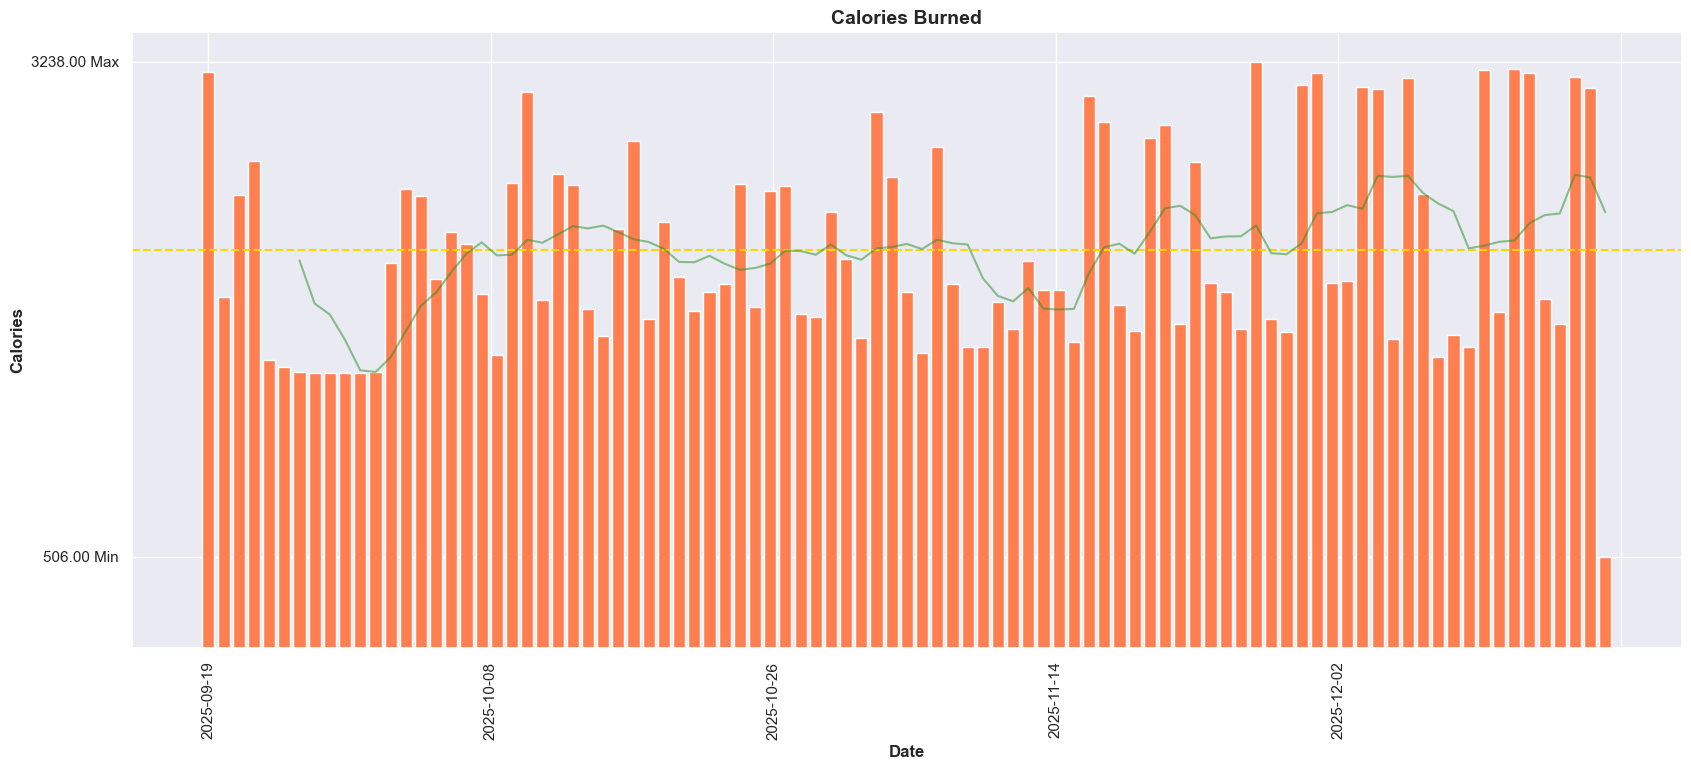

In [531]:
plt.figure(figsize=[20,8])
plt.bar(df_viz['Date'], df_viz['Calories'], color=MAIN_COLOR)
plt.axhline(y=df_viz['Calories'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Kilocalories {df_viz["Calories"].mean():.2f}')
plt.plot(df_viz['Date'], df_viz['rolling avg'], color=POSITIVE_REF_COLOR, alpha=0.5)
plt.xticks(rotation=90)
y_min = df_viz['Calories'].min()
y_max = df_viz['Calories'].max()
plt.yticks([y_min, y_max], [f'{y_min:.2f} Min', f'{y_max:.2f} Max'])
plt.title('Calories Burned', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Calories', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(abs(TIME_RANGE/ TIME_STEP)))
plt.show()

## Heart Rate Data

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these stri

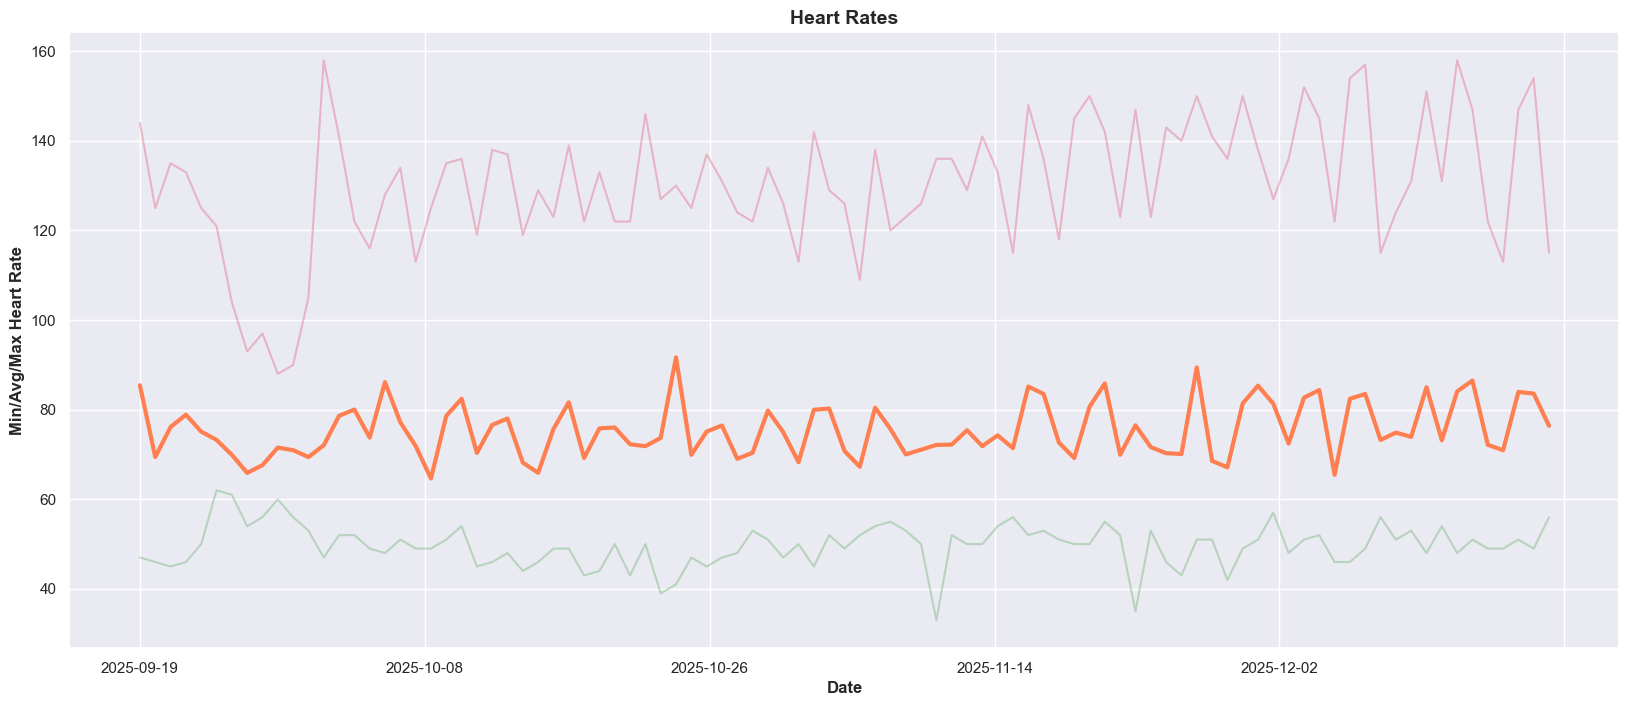

In [457]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Max Heart Rate'], color=NEGATIVE_REF_COLOR, alpha=.25)
plt.plot(df_viz['Date'], df_viz['Min Heart Rate'], color=POSITIVE_REF_COLOR, alpha=.25)
plt.plot(df_viz['Date'], df_viz['Average Heart Rate'], color=MAIN_COLOR, linewidth=3)
plt.title('Heart Rates', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Min/Avg/Max Heart Rate', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

Text(0.5, 1.0, 'Does More Sleep Mean Better Sleep?')

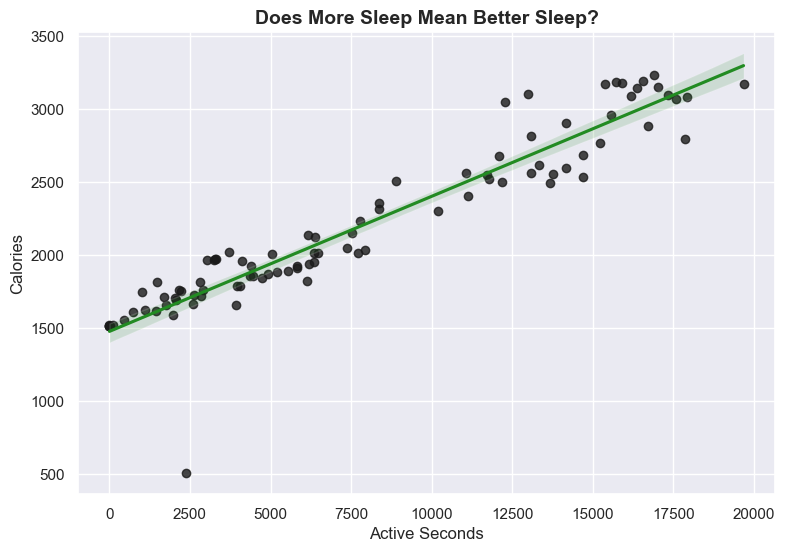

In [508]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Active Seconds',
            y='Calories',
            data=df_viz,
            # color='grey',
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.title('Does More Sleep Mean Better Sleep?', fontweight='bold', fontsize=14)

## Fitness Age

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


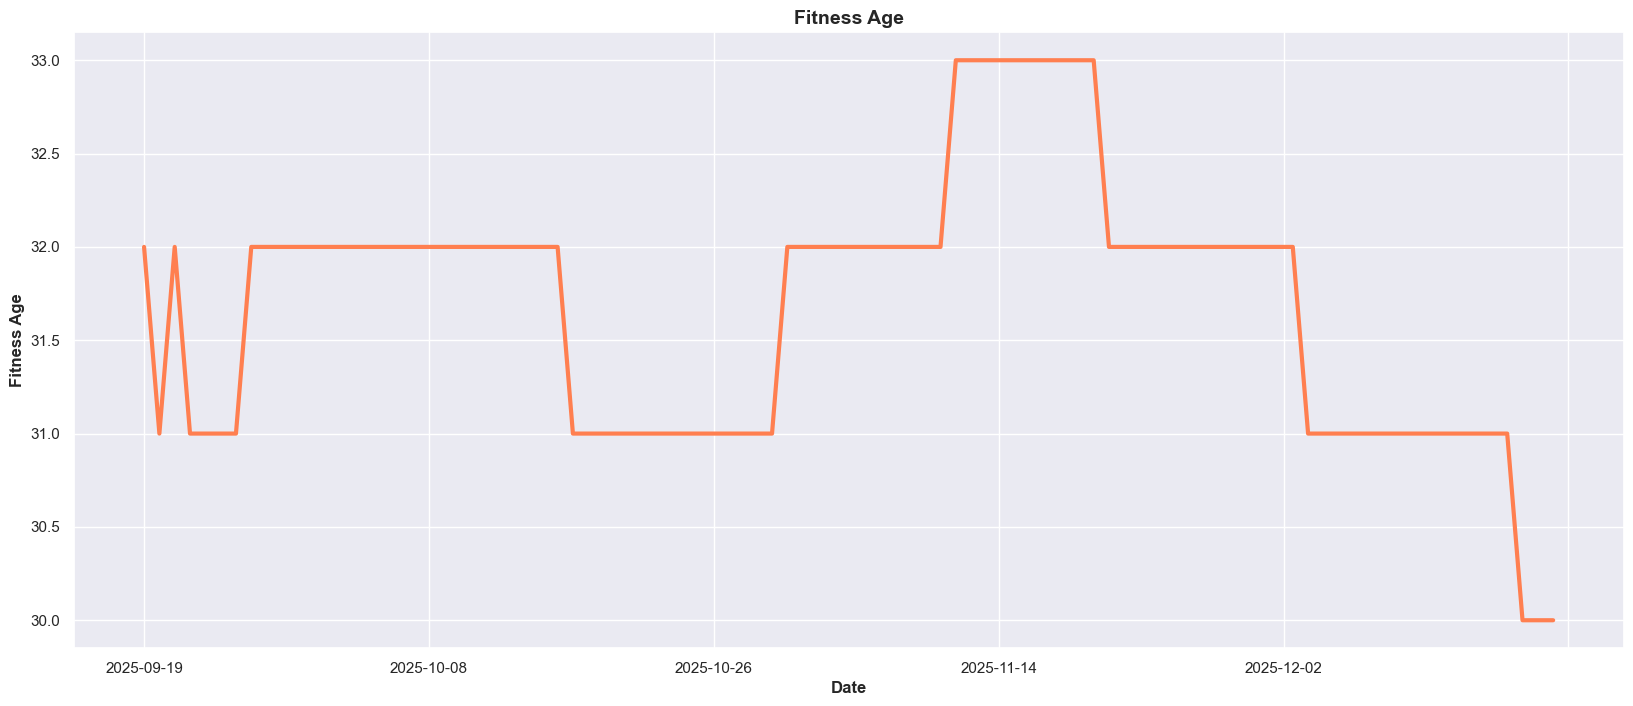

In [506]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Fitness Age'], color=MAIN_COLOR, linewidth=3)
plt.title('Fitness Age', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Fitness Age', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

Text(0.5, 1.0, 'Do Calories burned == a better Fitness Age?')

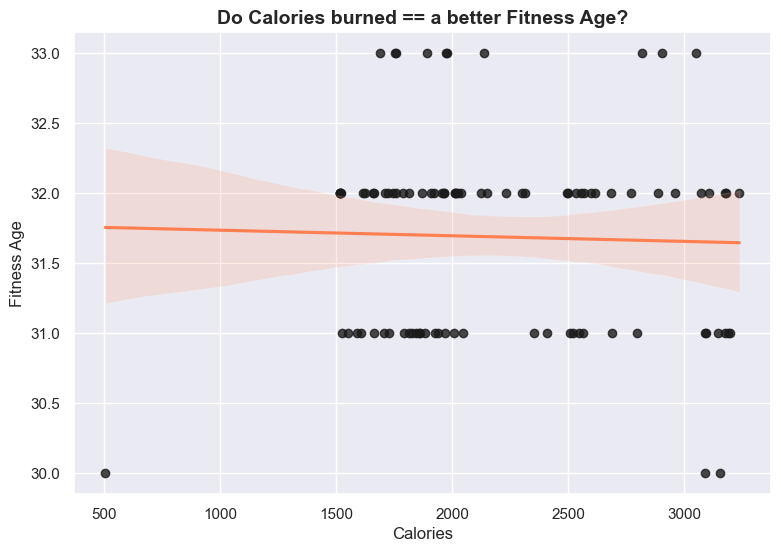

In [505]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Calories',
            y='Fitness Age',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': MAIN_COLOR},
            )
plt.title('Do Calories burned == a better Fitness Age?', fontweight='bold', fontsize=14)

## Total Steps Taken
That spike is from a hike in the Columbia River Gorge

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Figure size 2000x800 with 0 Axes>

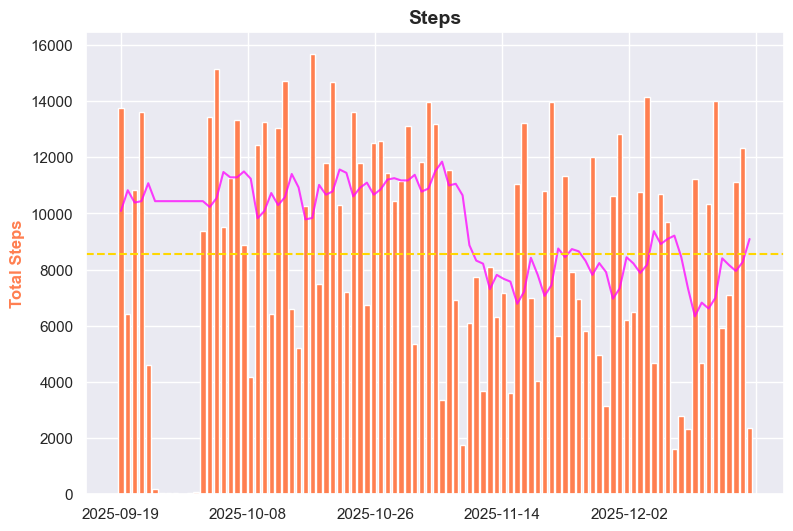

In [464]:
plt.figure(figsize=[20,8])

fix, ax1 = plt.subplots()

ax1.bar(df_viz['Date'], df_viz['Total Steps'], color=MAIN_COLOR)
ax1.plot(df_viz['Date'], df_viz['Daily Step Goal'], color='magenta', alpha=.75)
plt.axhline(y=df_viz['Total Steps'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz["Total Steps"].mean():.2f}')
y_min = df_viz['Total Steps'].min()
y_max = df_viz['Total Steps'].max()
ax1.set_ylabel('Total Steps', fontweight='bold', color=MAIN_COLOR)
#
# ax2 = ax1.twinx()
#
# ax2.plot(df_viz['Date'], df_viz['Calories'], color=POSITIVE_REF_COLOR, alpha=.25)
# ax2.set_ylabel('Calories', color=POSITIVE_REF_COLOR)

plt.title('Steps', fontweight='bold', fontsize=14)
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

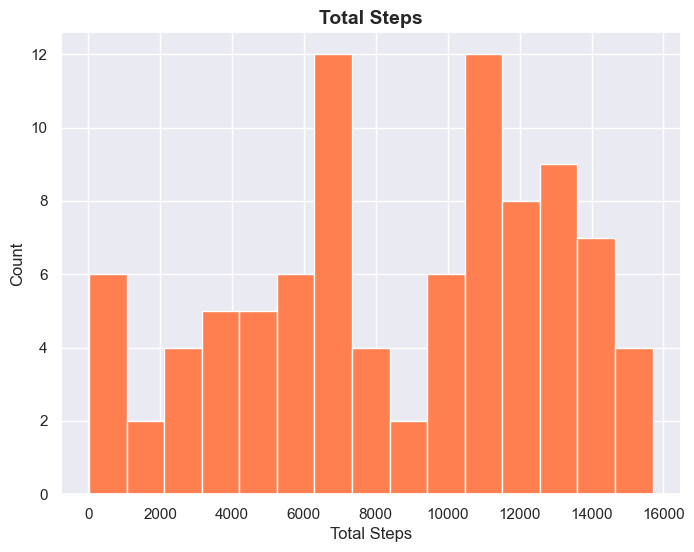

In [459]:
plt.figure(figsize=[8,6])
plt.hist(df_viz['Total Steps'], bins=15, color=MAIN_COLOR)
plt.title('Total Steps', fontsize=14, weight='bold')
plt.xlabel('Total Steps')
plt.ylabel('Count')
plt.show()

## Total Miles Walked


In [460]:
df_viz_tmp = df_viz[['Date', 'Total Distance Meters']]
df_viz_tmp.loc[:, 'Total Distance Meters'] = df_viz_tmp['Total Distance Meters'] / 1609

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


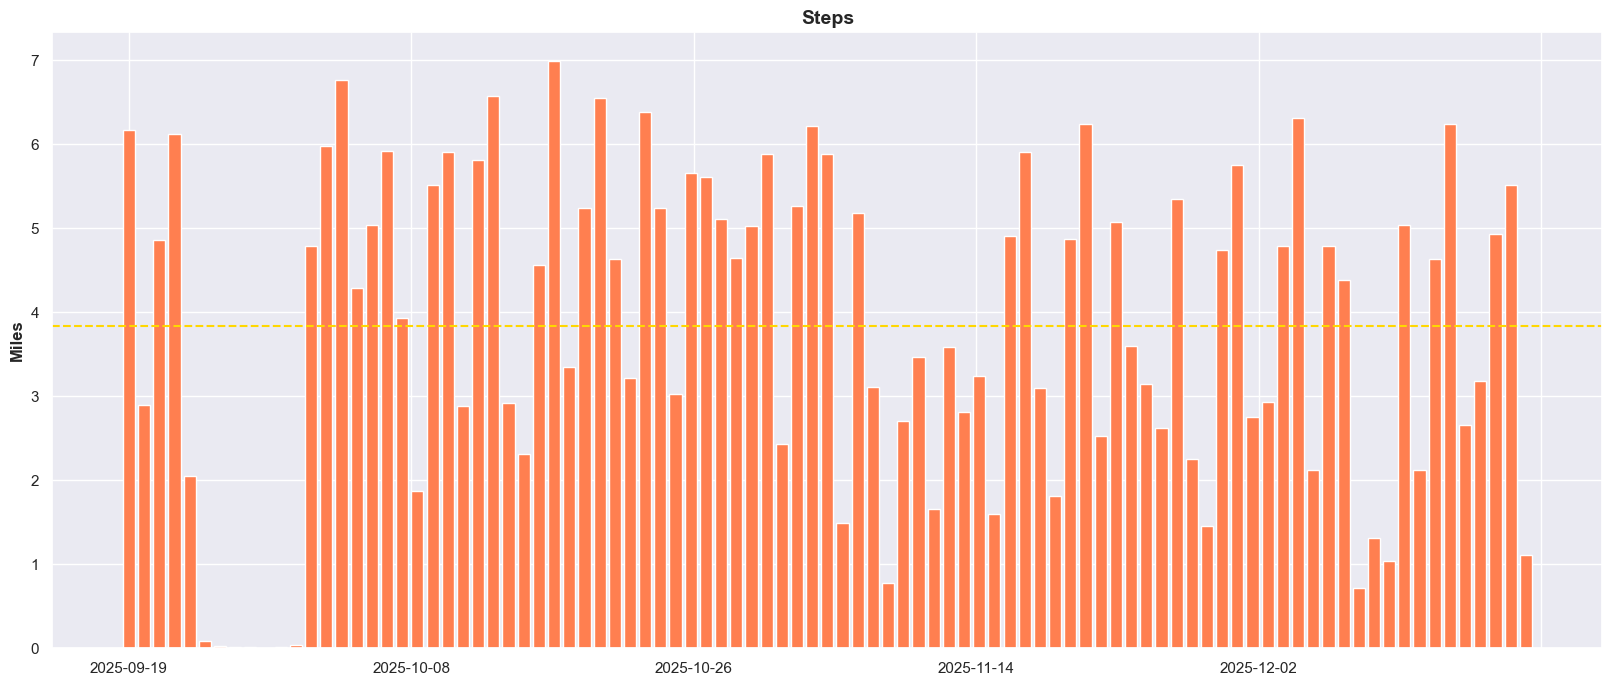

In [461]:
plt.figure(figsize=[20,8])
plt.bar(df_viz_tmp['Date'], df_viz_tmp['Total Distance Meters'], color=MAIN_COLOR)
plt.axhline(y=df_viz_tmp['Total Distance Meters'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz_tmp["Total Distance Meters"].mean():.2f}')
y_min = df_viz_tmp['Total Distance Meters'].min()
y_max = df_viz_tmp['Total Distance Meters'].max()
plt.title('Steps', fontweight='bold', fontsize=14)
plt.ylabel('Miles', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

In [462]:
df_viz_tmp = df_viz[['Active Seconds', 'Sedentary Seconds']].mean()/3600
df_viz_tmp = pd.DataFrame(df_viz_tmp).T.astype('Int64')
df_viz_tmp

TypeError: cannot safely cast non-equivalent object to int64

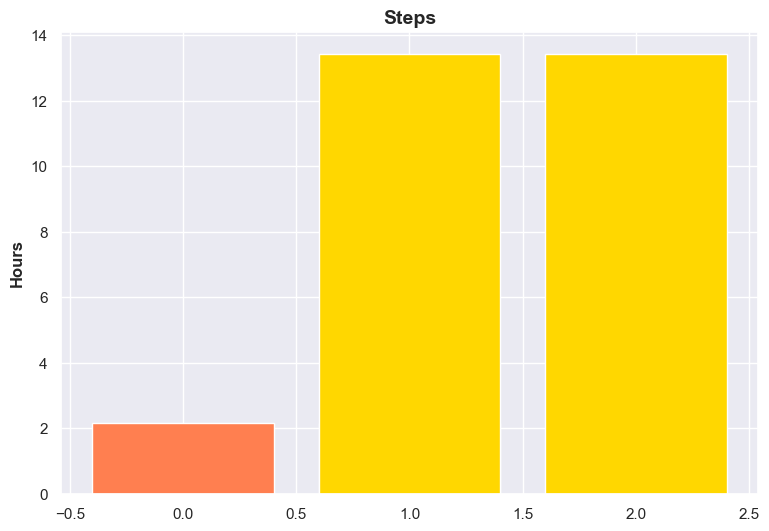

In [469]:

plt.bar([0, 1], df_viz_tmp['Active Seconds'], color=MAIN_COLOR)
plt.bar([x + 1 for x in [0, 1]], df_viz_tmp['Sedentary Seconds'], color=REF_COLOR)
plt.title('Steps', fontweight='bold', fontsize=14)
plt.ylabel('Hours', fontweight='bold')
plt.show()

## Sleep Duration

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these stri

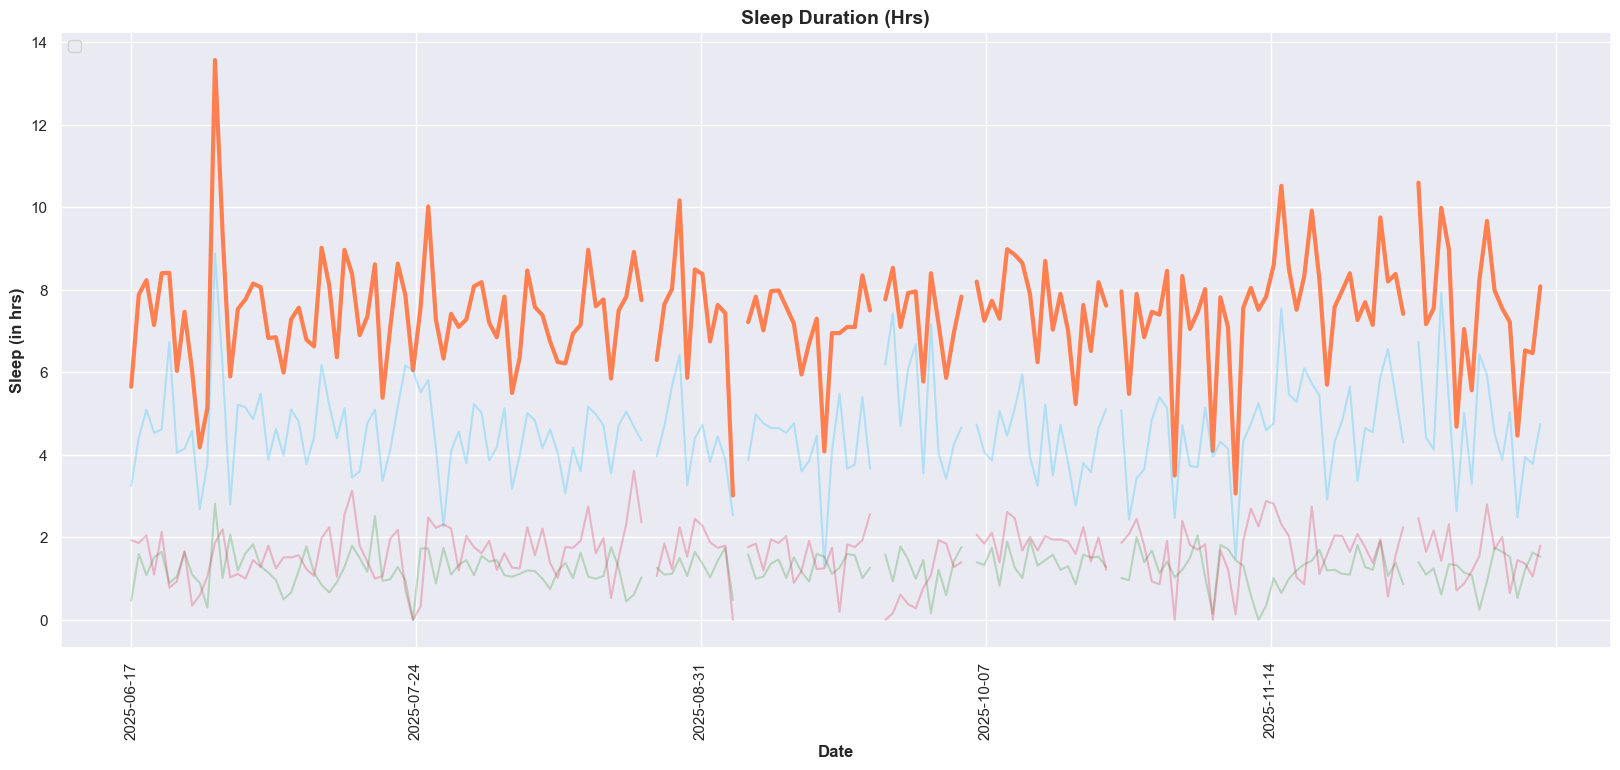

In [379]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Sleep Time Seconds'] / 3600, color=MAIN_COLOR, linewidth=3)
plt.plot(df_viz['Date'], df_viz['Light Sleep Seconds'] / 3600, color='deepskyblue', alpha=.25)
plt.plot(df_viz['Date'], df_viz['Deep Sleep Seconds'] / 3600, color='forestgreen', alpha=.25)
plt.plot(df_viz['Date'], df_viz['Rem Sleep Seconds'] / 3600, color='crimson', alpha=.25)
plt.legend(loc='upper left')
plt.title('Sleep Duration (Hrs)', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.xticks(rotation=90)
plt.ylabel('Sleep (in hrs)', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

## Sleep Score

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


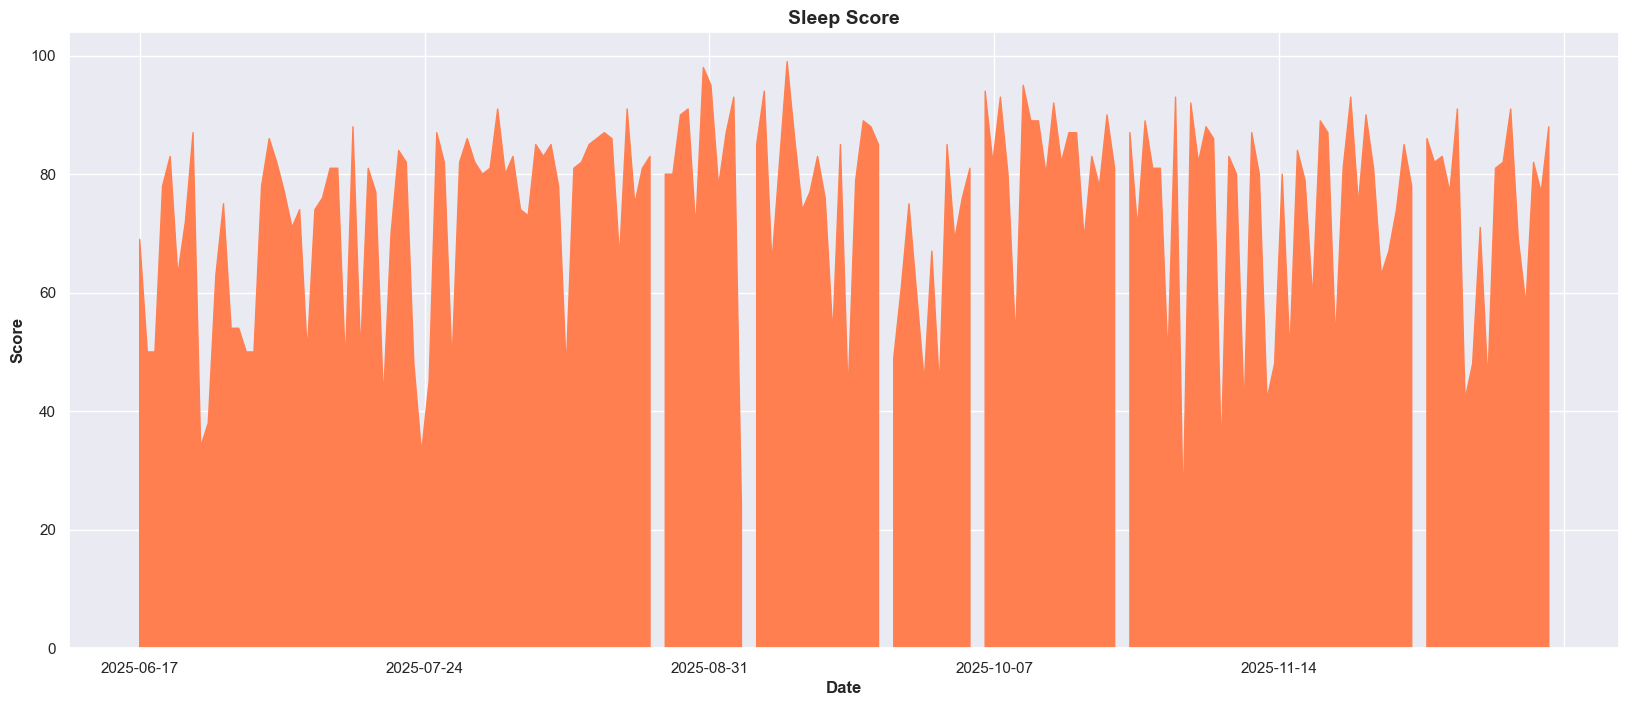

In [338]:
plt.figure(figsize=[20,8])
plt.stackplot(df_viz['Date'], df_viz['Sleep Score'], color=MAIN_COLOR)
plt.title('Sleep Score', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))

## What my aggregated sleep scores are

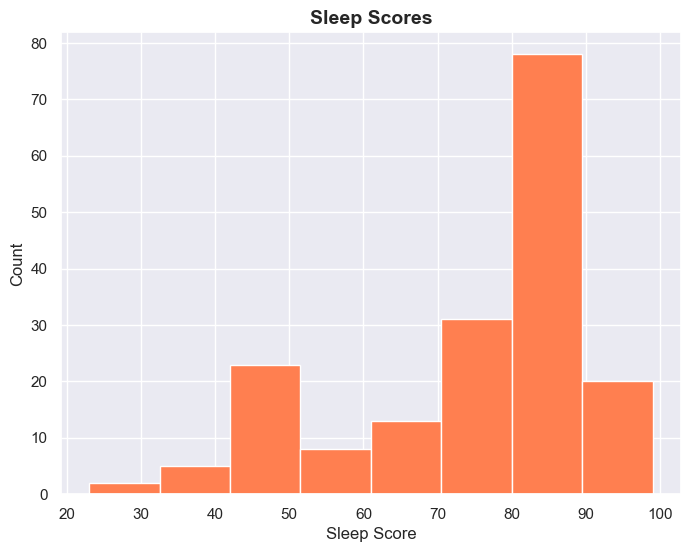

In [339]:
plt.figure(figsize=[8,6])
plt.hist(df_viz['Sleep Score'], bins=8, color=MAIN_COLOR)
plt.title('Sleep Scores', fontsize=14, weight='bold')
plt.xlabel('Sleep Score')
plt.ylabel('Count')
plt.show()

## Does More Sleep mean Better sleep?

In [340]:
df_viz_tmp = df_viz.loc[:, ['Sleep Score', 'Sleep Time Seconds']]

In [341]:
df_viz_tmp.loc[:, 'Sleep Time Seconds'] = df_viz_tmp['Sleep Time Seconds'] /3600
df_viz_tmp

,Sleep Score,Sleep Time Seconds
167,69.0,5.650000
168,50.0,7.883333
169,50.0,8.233333
170,78.0,7.145278
171,83.0,8.400000
...,...,...
349,58.0,4.466667
350,82.0,6.533333
351,77.0,6.466667
352,88.0,8.083333


Text(0.5, 1.0, 'Does More Sleep Mean Better Sleep?')

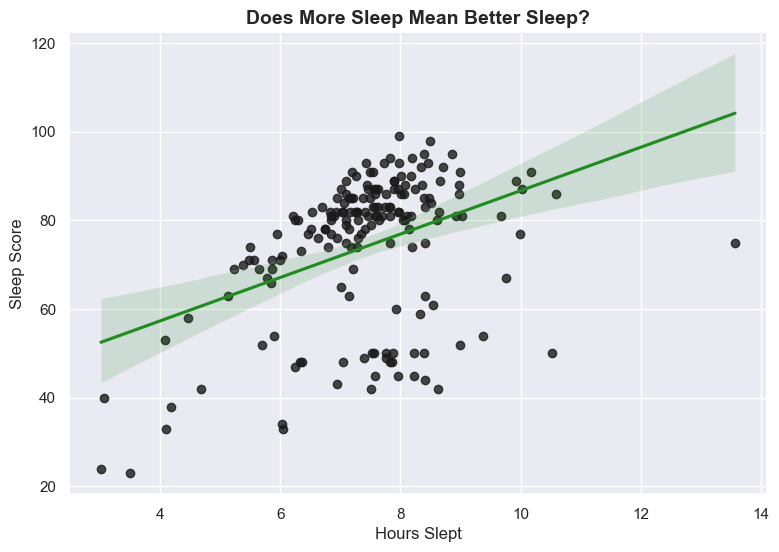

In [342]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Sleep Time Seconds',
            y='Sleep Score',
            data=df_viz_tmp,
            # color='grey',
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.xlabel('Hours Slept')
plt.ylabel('Sleep Score')
plt.title('Does More Sleep Mean Better Sleep?', fontweight='bold', fontsize=14)

## Does Good Sleep mean Better Body Battery Charge?
It looks like the trend is that the better sleep I get the more body battery I have

Text(0.5, 1.0, 'Quantifying if Sleep Score == More Battery')

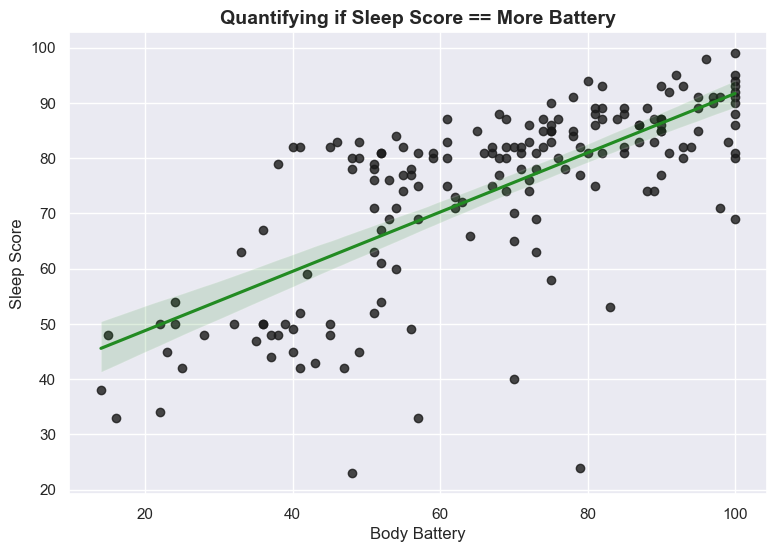

In [343]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Body Battery',
            y='Sleep Score',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.title('Quantifying if Sleep Score == More Battery', fontweight='bold', fontsize=14)

## Do I Burn More Calories with Better Sleep?
The trend shows that it's neutral and it doesn't matter how much sleep I get.

Text(0.5, 1.0, 'Do I Get Better Sleep with More Calories Burned?')

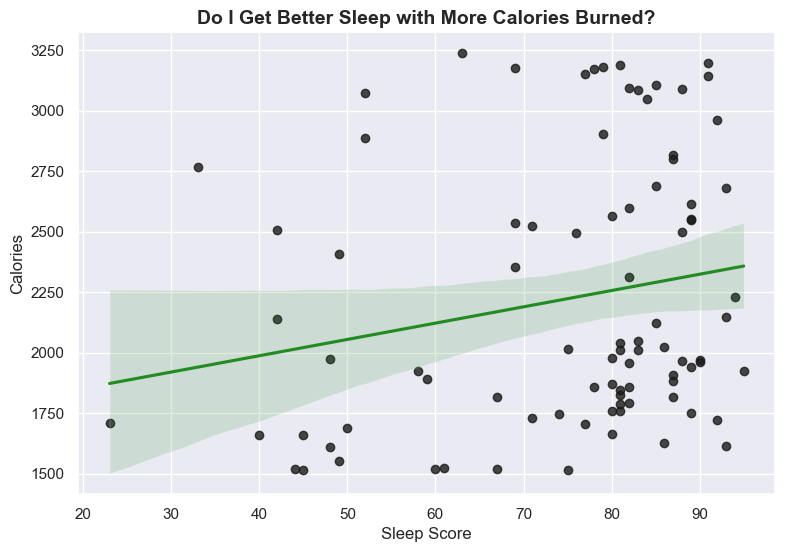

In [489]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Sleep Score',
            y='Calories',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.title('Do I Get Better Sleep with More Calories Burned?', fontweight='bold', fontsize=14)

Text(0.5, 1.0, 'Do I Get Better Sleep with More Steps?')

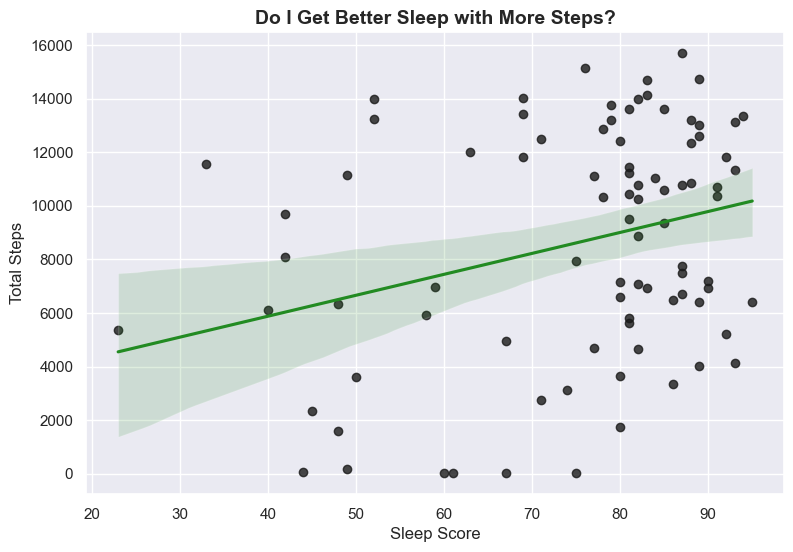

In [486]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Sleep Score',
            y='Total Steps',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.title('Do I Get Better Sleep with More Steps?', fontweight='bold', fontsize=14)

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these stri

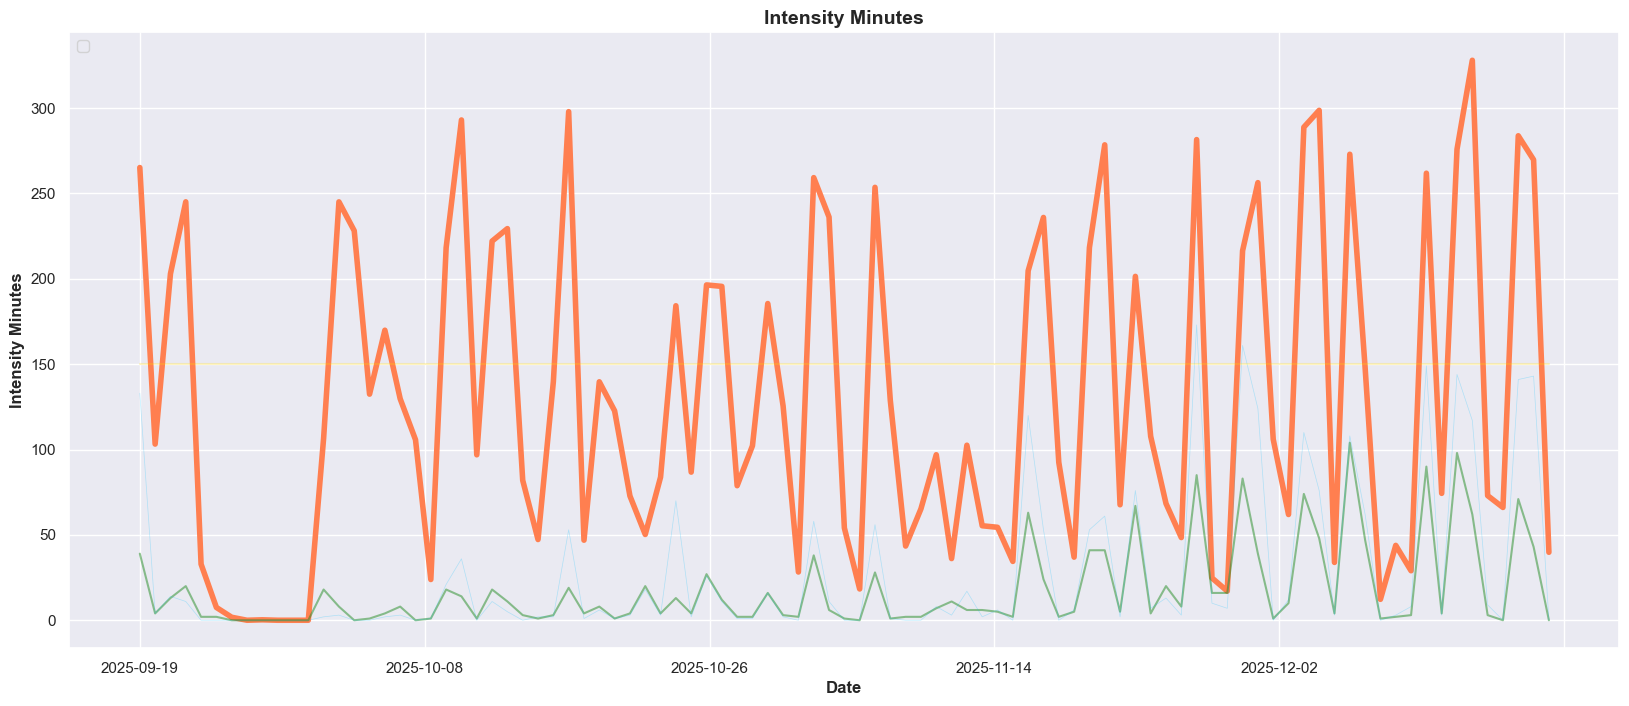

In [502]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Active Seconds'] / 60, color=MAIN_COLOR, linewidth=4)
plt.plot(df_viz['Date'], df_viz['Vigorous Intensity Minutes'], color=POSITIVE_REF_COLOR, alpha=.5)
plt.plot(df_viz['Date'], df_viz['Moderate Intensity Minutes'], color='deepskyblue', alpha=.25, linewidth=.5)
plt.plot(df_viz['Date'], df_viz['Intensity Minutes Goal'], color=REF_COLOR, alpha=.25)
plt.legend(loc='upper left')
plt.title('Intensity Minutes', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Intensity Minutes', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

## Stress Data
The more stressed I am, the worse sleep I get

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Figure size 2000x800 with 0 Axes>

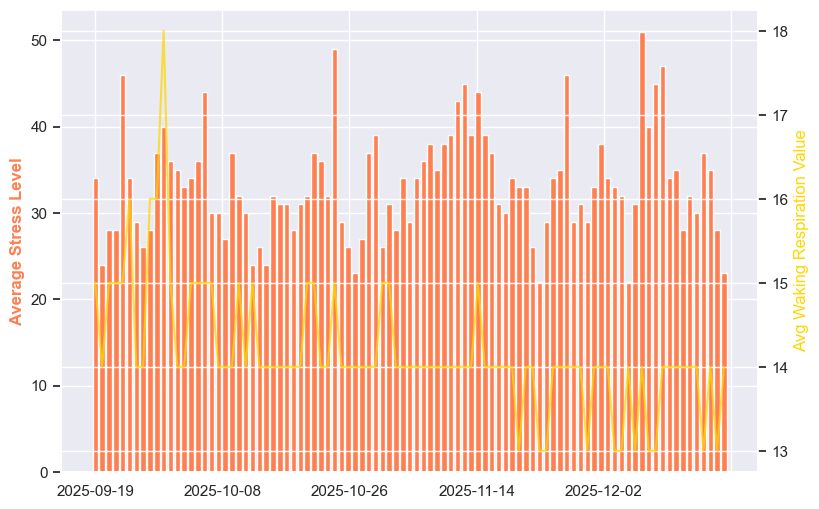

In [522]:
plt.figure(figsize=[20,8])
fix, ax1 = plt.subplots()

ax1.bar(df_viz['Date'], df_viz['Average Stress Level'], color=MAIN_COLOR)
ax1.set_ylabel('Average Stress Level', fontweight='bold', color=MAIN_COLOR)

ax2 = ax1.twinx()

ax2.plot(df_viz['Date'], df_viz['Avg Waking Respiration Value'], color=REF_COLOR, alpha=.75)
ax2.set_ylabel('Avg Waking Respiration Value', color=REF_COLOR)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

Text(0.5, 1.0, 'How Quality of Sleep effects Stress Levels')

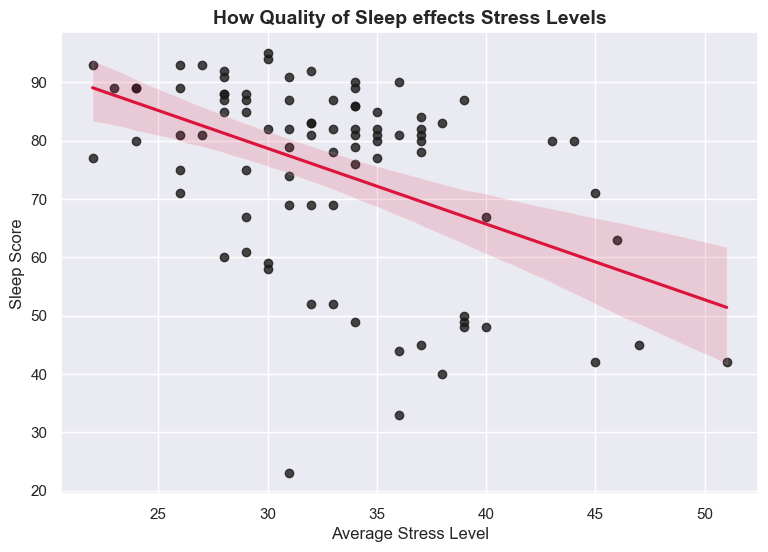

In [525]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Average Stress Level',
            y='Sleep Score',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': NEGATIVE_REF_COLOR},
            )
plt.xlabel('Average Stress Level')
plt.ylabel('Sleep Score')
plt.title('How Quality of Sleep effects Stress Levels', fontweight='bold', fontsize=14)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'BALANCED'),
  Text(1, 0, 'BALANCED_AWAKE'),
  Text(2, 0, 'CALM'),
  Text(3, 0, 'STRESSFUL'),
  Text(4, 0, 'STRESSFUL_AWAKE'),
  Text(5, 0, 'UNKNOWN'),
  Text(6, 0, 'VERY_STRESSFUL')])

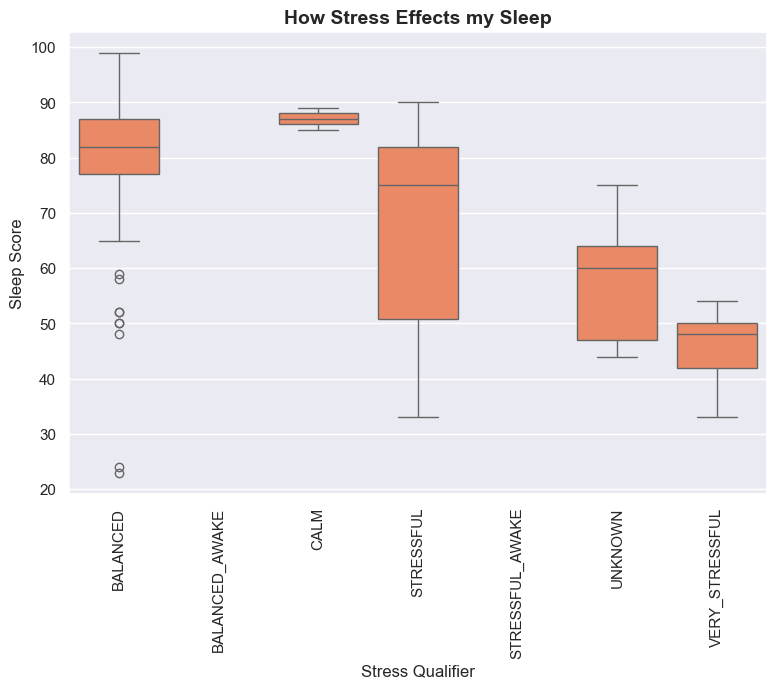

In [382]:
sns.boxplot(df_viz.sort_values('Stress Qualifier'), x='Stress Qualifier', y='Sleep Score', color=MAIN_COLOR)
plt.title('How Stress Effects my Sleep', fontweight='bold', fontsize=14)
plt.xticks(rotation=90)
plt.xticks(rotation=90)

## How my Body Battery effects my Stress Levels
The lower my body battery at the beginning of hte day, the more likely I am to be more stresed

Text(0.5, 1.0, 'How My Body Battery Effects my Stress Levels')

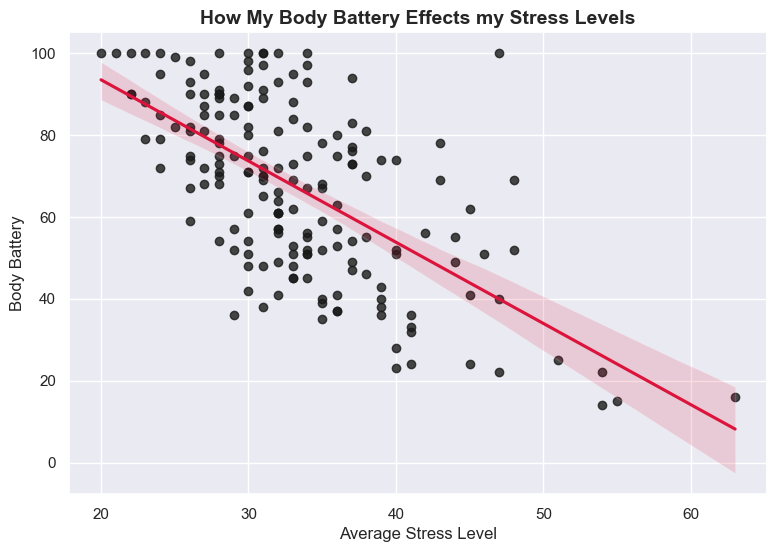

In [346]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Average Stress Level',
            y='Body Battery',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': NEGATIVE_REF_COLOR},
            )
plt.title('How My Body Battery Effects my Stress Levels', fontweight='bold', fontsize=14)

## My Stress Levels and Sleep

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_78794/684443348.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.swarmplot(x='Sleep Quality',


Text(0.5, 1.0, 'How Stress Effects My Sleep')

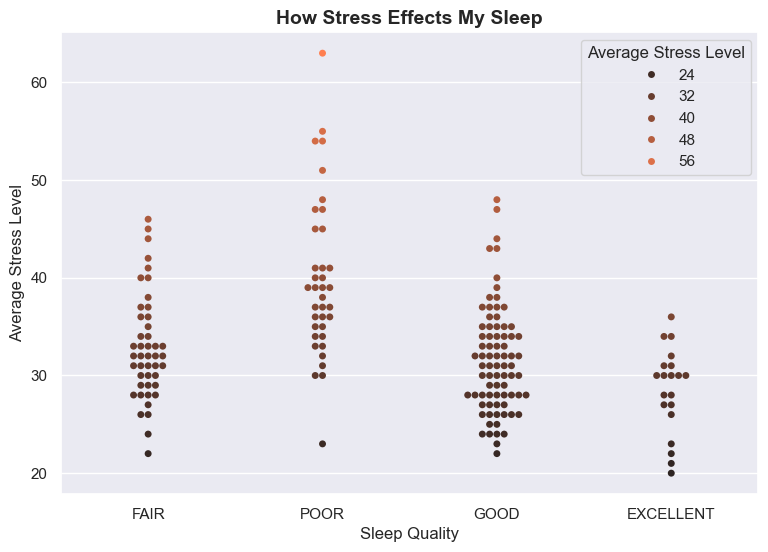

In [367]:
sns.set(rc={'figure.figsize': (9,6)})
sns.swarmplot(x='Sleep Quality',
              y='Average Stress Level',
              data=df_viz,
              color=MAIN_COLOR,
              hue='Average Stress Level',
            )
plt.ylabel('Average Stress Level')
plt.xlabel('Sleep Quality')
plt.title('How Stress Effects My Sleep', fontweight='bold', fontsize=14)

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_78794/2290305354.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.stripplot(x='Sleep Quality',


Text(0.5, 1.0, 'How High Stress Effects my Quality of Sleep')

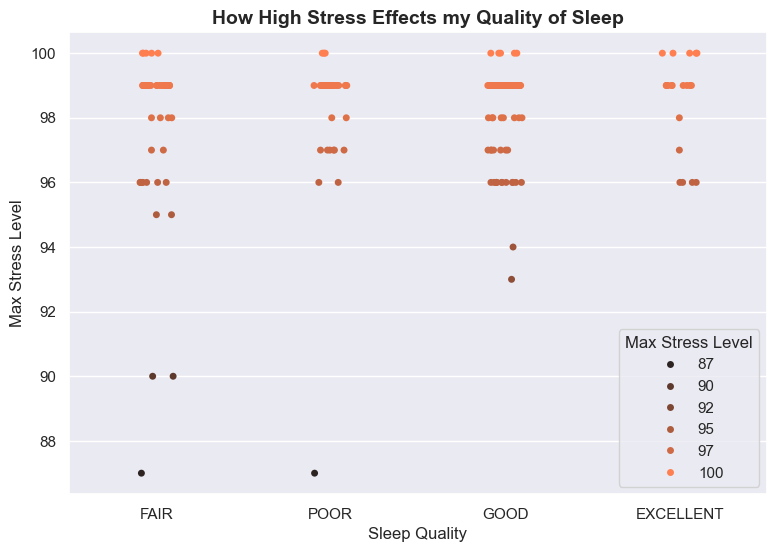

In [368]:
sns.set(rc={'figure.figsize': (9,6)})
sns.stripplot(x='Sleep Quality',
              y='Max Stress Level',
              data=df_viz,
              color=MAIN_COLOR,
              hue='Max Stress Level',
            )
plt.ylabel('Max Stress Level')
plt.xlabel('Sleep Quality')
plt.title('How High Stress Effects my Quality of Sleep', fontweight='bold', fontsize=14)

In [369]:
df_viz_tmp = df_viz[['Stress Seconds', 'Sleep Quality']]
# df_viz_tmp.loc[:, 'Stress Seconds'] = df_viz_tmp['Stress Seconds'] / 3600

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_78794/2043759112.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.swarmplot(df_viz_tmp, y='Stress Seconds', x='Sleep Quality', hue='Stress Seconds', color=MAIN_COLOR)


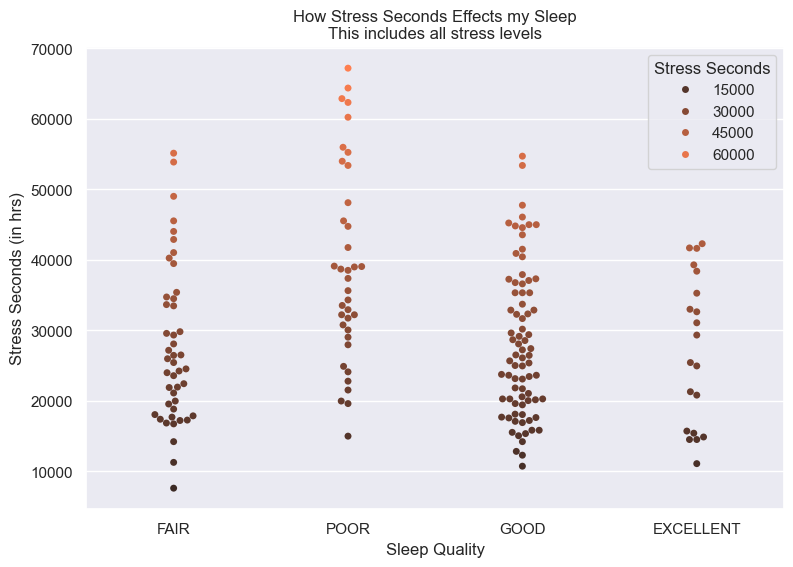

In [370]:
plt.figure(figsize=(9, 6)) # Optional: Adjust figure size
sns.swarmplot(df_viz_tmp, y='Stress Seconds', x='Sleep Quality', hue='Stress Seconds', color=MAIN_COLOR)
plt.ylabel('Stress Seconds (in hrs)')
plt.title('How Stress Seconds Effects my Sleep\nThis includes all stress levels') # Optional: Add a title
plt.show() # Display the plot

## How Does Stress Effect My Heart Rate?

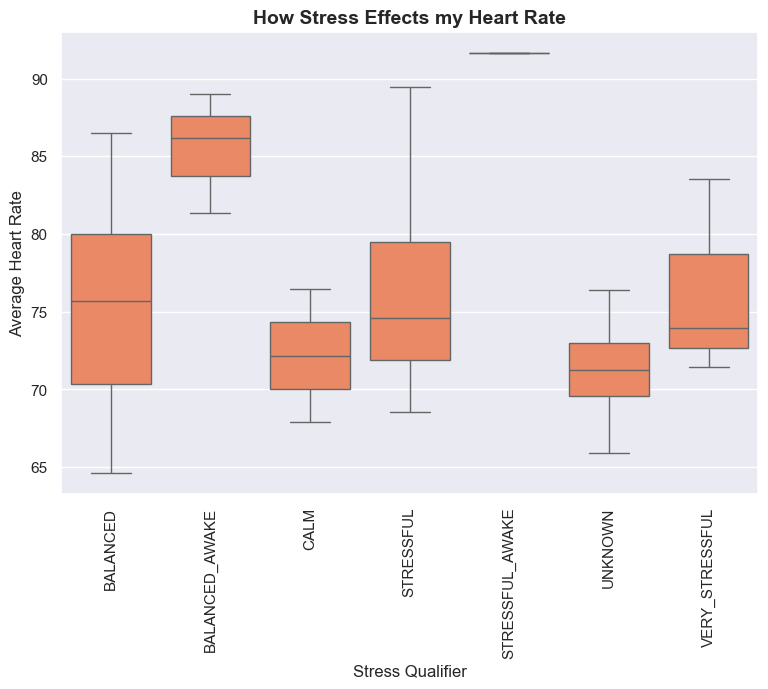

In [383]:
plt.figure(figsize=(9, 6))
sns.boxplot(df_viz.sort_values('Stress Qualifier'), x='Stress Qualifier', y='Average Heart Rate', color=MAIN_COLOR)
plt.title('How Stress Effects my Heart Rate', fontweight='bold', fontsize=14)
plt.xticks(rotation=90)
plt.show() # Display the plot

In [373]:
df_viz_tmp = df_viz[['Stress Seconds', 'Calories']]
df_viz_tmp.loc[:, 'Stress Seconds'] = df_viz_tmp['Stress Seconds'] / 3600

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_78794/1822918326.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 6.81666667 10.38333333  6.33333333  4.83333333  3.41666667 11.91666667
 12.65       14.83333333 15.         17.46666667 14.96666667 10.96666667
 15.55       17.88333333  8.81666667  9.9         5.86666667  9.81666667
 12.1        11.18333333 13.61666667  7.21666667  6.7         4.96666667
  5.43333333  5.71666667 11.23333333 10.85        6.56666667 10.75
  5.45        7.8        12.65        7.35       12.5         5.85
  9.15       11.6        10.86666667  9.81666667  4.4         7.76666667
 11.53333333  9.13333333  8.98333333  4.78333333  8.38333333  4.28333333
  5.4         8.96666667 11.4         8.21666667  3.95        8.16666667
  5.03333333  5.23333333 10.7        10.16666667  6.93333333  4.9
  7.61666667  3.56666667  4.26666667  9.65        9.8         9.58333333
  7.36666667  4.

Text(0.5, 1.0, "Do I Burn more Calories when I'm Stressed?")

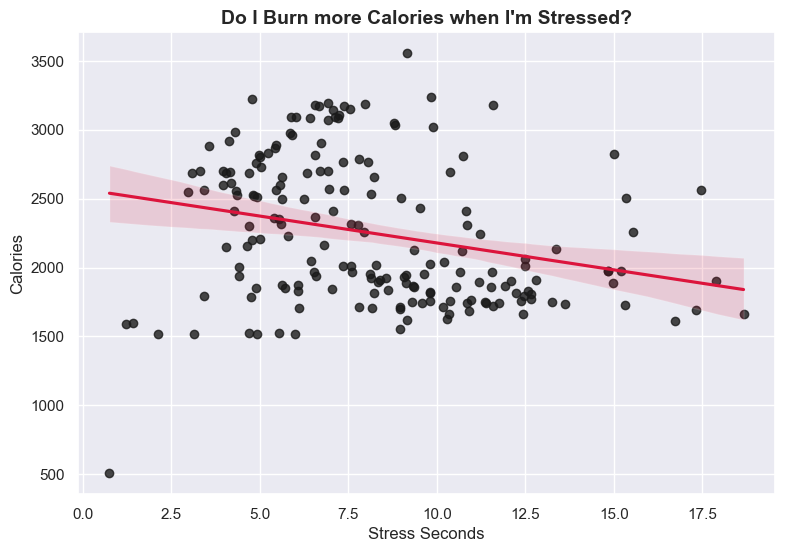

In [374]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Stress Seconds',
            y='Calories',
            data=df_viz_tmp,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': NEGATIVE_REF_COLOR},
            )
plt.title('Do I Burn more Calories when I\'m Stressed?', fontweight='bold', fontsize=14)

Text(0.5, 1.0, "Do I Burn more Calories when I'm Stressed?")

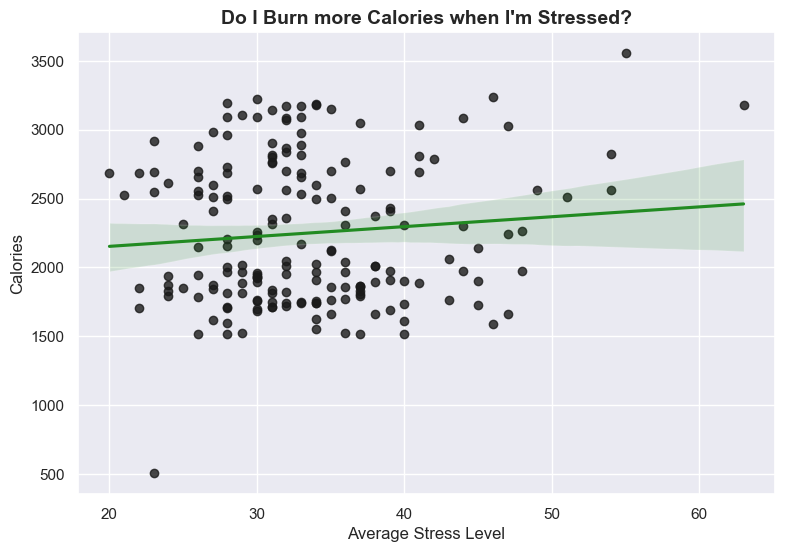

In [375]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Average Stress Level',
            y='Calories',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.title('Do I Burn more Calories when I\'m Stressed?', fontweight='bold', fontsize=14)

In [376]:
df_viz_tmp = df_viz[['Average Stress Level', 'Active Seconds', 'Highly Active Seconds']]

Text(0.5, 1.0, 'Is there a correlation between my active seconds and stress?')

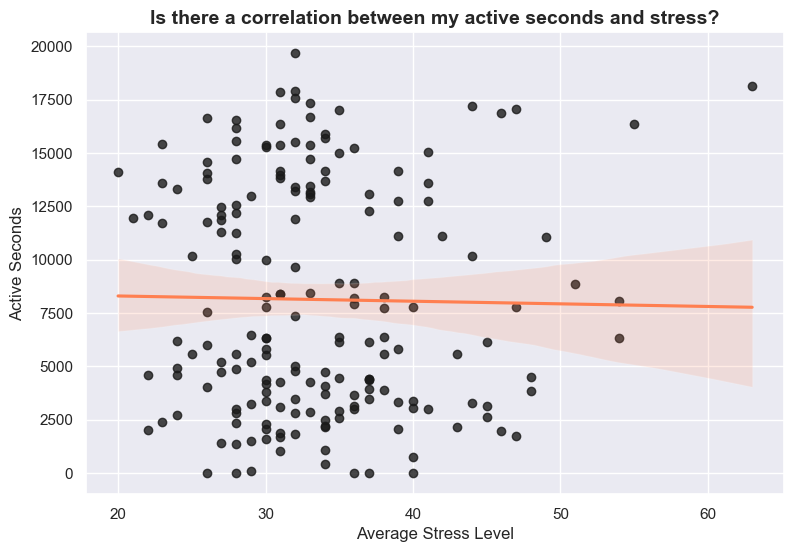

In [377]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Average Stress Level',
            y='Active Seconds',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': MAIN_COLOR},
            )
plt.title('Is there a correlation between my active seconds and stress?', fontweight='bold', fontsize=14)

Text(0.5, 1.0, 'Is there a correlation between my high active seconds and stress?')

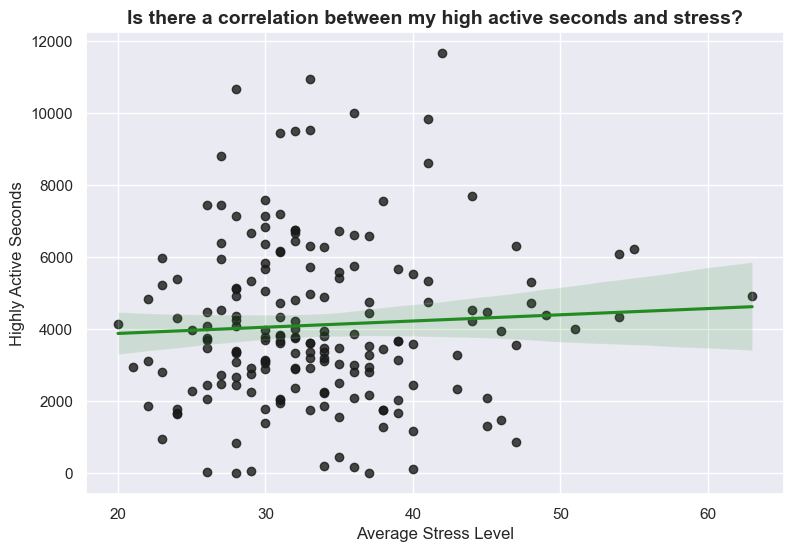

In [378]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Average Stress Level',
            y='Highly Active Seconds',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.title('Is there a correlation between my high active seconds and stress?', fontweight='bold', fontsize=14)